In [2]:
df_gasto = pd.read_csv(
    "../data/raw/gasto_saude_uf.csv",
    encoding="latin1",
    sep=";",
    skiprows=3,
    quotechar='"',
    decimal=","
)

df_gasto.head(10)

NameError: name 'pd' is not defined

In [ ]:
# Remove a coluna Total
df_gasto = df_gasto.drop(columns=["Total"])

# Transforma de formato largo pra longo
anos = [col for col in df_gasto.columns if col.strip().isdigit()]

df_gasto_long = df_gasto.melt(
    id_vars=["UF"],
    value_vars=anos,
    var_name="ano",
    value_name="gasto_saude_per_capita"
)

df_gasto_long["ano"] = df_gasto_long["ano"].astype(int)
df_gasto_long = df_gasto_long.rename(columns={"UF": "uf"})

# Mantém só o período que nos interessa (2013-2022, mesmo do dataset de vacinação)
df_gasto_long = df_gasto_long[df_gasto_long["ano"].between(2013, 2022)]

print(df_gasto_long.shape)
df_gasto_long.head(10)

(270, 3)


,uf,ano,gasto_saude_per_capita
0,Rondônia,2013,502.62
1,Acre,2013,990.70
2,Amazonas,2013,630.89
3,Roraima,2013,922.97
4,Pará,2013,235.98
5,Amapá,2013,799.43
6,Tocantins,2013,840.61
7,Maranhão,2013,236.43
8,Piauí,2013,270.37
9,Ceará,2013,266.60


In [ ]:
df_gasto_long.to_csv("../data/processed/gasto_saude_por_uf.csv", index=False, encoding="utf-8")
print("Arquivo salvo!")

Arquivo salvo!


In [ ]:
# Carrega a cobertura vacinal já tratada
df_cobertura = pd.read_csv("../data/processed/cobertura_vacinal_por_uf.csv")

# Calcula a cobertura média (das 4 vacinas) por UF/ano, pra comparar com o gasto
cobertura_media = (
    df_cobertura
    .groupby(["uf", "ano"])["cobertura"]
    .mean()
    .reset_index()
    .rename(columns={"cobertura": "cobertura_media"})
)

# Junta com o gasto em saúde
df_cruzado = pd.merge(cobertura_media, df_gasto_long, on=["uf", "ano"], how="inner")

print(df_cruzado.shape)
df_cruzado.head(10)

NameError: name 'pd' is not defined

In [ ]:
correlacao = df_cruzado["gasto_saude_per_capita"].corr(df_cruzado["cobertura_media"])
print(f"Correlação entre gasto em saúde e cobertura vacinal: {correlacao:.3f}")

NameError: name 'df_cruzado' is not defined

In [ ]:
# Correlação por estado individual (ao longo dos anos)
correlacao_por_estado = (
    df_cruzado.groupby("uf")
    .apply(lambda x: x["gasto_saude_per_capita"].corr(x["cobertura_media"]))
    .reset_index(name="correlacao")
    .sort_values("correlacao")
)

print(correlacao_por_estado)

NameError: name 'df_cruzado' is not defined

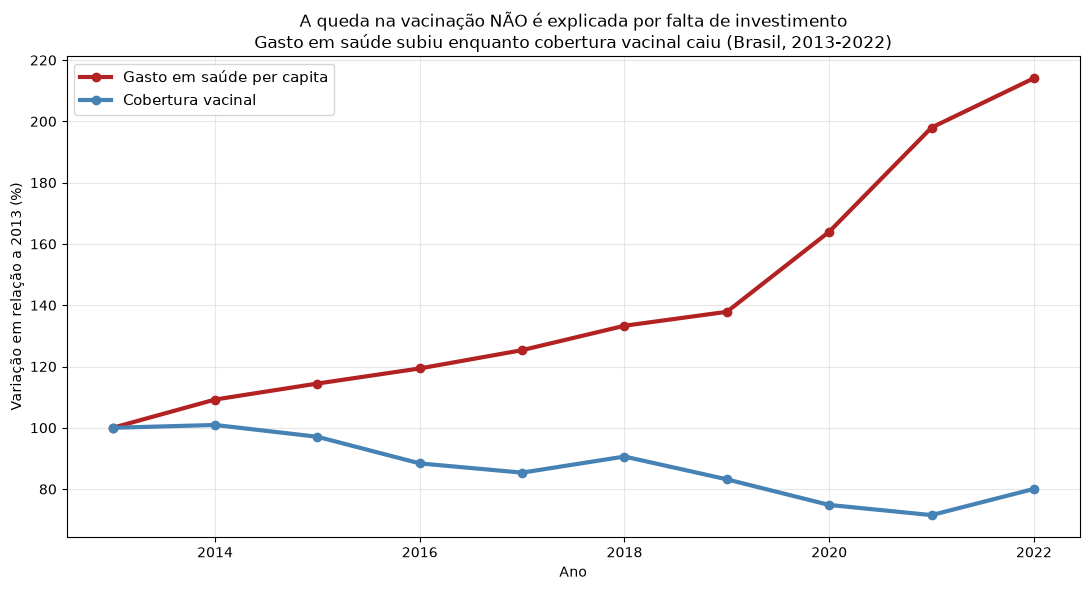

In [ ]:
media_nacional = df_cruzado.groupby("ano")[["gasto_saude_per_capita", "cobertura_media"]].mean().reset_index()

base_gasto = media_nacional["gasto_saude_per_capita"].iloc[0]
base_cobertura = media_nacional["cobertura_media"].iloc[0]

media_nacional["indice_gasto"] = (media_nacional["gasto_saude_per_capita"] / base_gasto) * 100
media_nacional["indice_cobertura"] = (media_nacional["cobertura_media"] / base_cobertura) * 100

plt.figure(figsize=(11, 6))
plt.plot(media_nacional["ano"], media_nacional["indice_gasto"], color="firebrick", marker="o", linewidth=3, label="Gasto em saúde per capita")
plt.plot(media_nacional["ano"], media_nacional["indice_cobertura"], color="steelblue", marker="o", linewidth=3, label="Cobertura vacinal")

plt.title("A queda na vacinação NÃO é explicada por falta de investimento\nGasto em saúde subiu enquanto cobertura vacinal caiu (Brasil, 2013-2022)", fontsize=12)
plt.xlabel("Ano")
plt.ylabel("Variação em relação a 2013 (%)")
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../dashboard/grafico_correlacao_gasto_cobertura.png", dpi=150, bbox_inches="tight")
plt.show()